In [2]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

import cmasher as cmr
import numpy as np
import pickle

from utils.misc.results_saving import save_results, load_results, load_results_for_model_and_revisions, load_all_results


plt.rcParams.update({'font.size': 14})

# Increasing Randomness

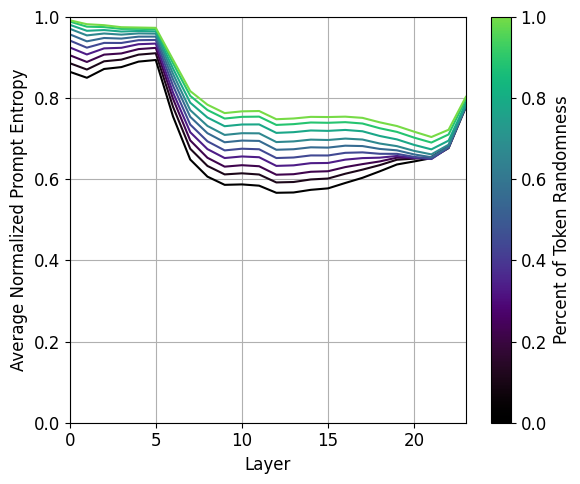

In [ ]:
with open('small_results/pythia_randomness.pkl', 'rb') as f:
    randomness_results = pickle.load(f)

fig, ax = plt.subplots(figsize=(6, 5))
randomness_levels = list(randomness_results.keys())
colors = cmr.lavender(np.linspace(0, 1, len(randomness_levels)))
cmap = cmr.lavender
norm = plt.Normalize(vmin=0, vmax=1)

PLOT_STDEV = False
PLOT_DIPTEST = False
normalization = 'maxEntropy'

for randomness_level, color in zip(randomness_levels, colors):
    if PLOT_STDEV:
        stddev = np.std(randomness_results[randomness_level][normalization], axis=0)
    elif PLOT_DIPTEST:
        layerwise_dipstats = [diptest.dipstat(randomness_results[randomness_level][normalization][:, layer]) for layer in range(randomness_results[randomness_level][normalization].shape[1])]
        ax.plot(layerwise_dipstats, color=color)
    else:
        ax.plot(randomness_results[randomness_level][normalization].mean(axis=0), color=color)
ax.set_xlabel("Layer")
ax.set_ylabel("Average Normalized Prompt Entropy")
#ax.set_ylim(0, 1)
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Percent of Token Randomness')
plt.tight_layout()
plt.savefig('figures/pythia_increasing_randomness.pdf')

# Sentences with Increasing Repetition

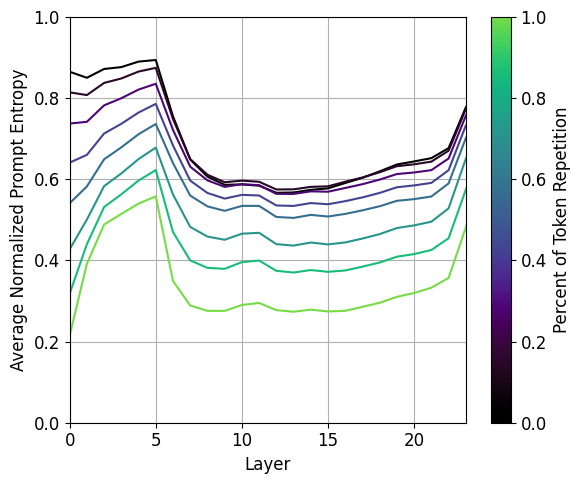

In [ ]:
with open('small_results/pythia_repetition.pkl', 'rb') as f:
    repetition_results = pickle.load(f)

# plot pythia repetition
fig, ax = plt.subplots(figsize=(6, 5))
repetition_levels = list(repetition_results.keys())
colors = cmr.lavender(np.linspace(0, 1, len(repetition_levels)))
cmap = cmr.lavender
norm = plt.Normalize(vmin=0, vmax=1)

PLOT_STDEV = False
PLOT_DIPTEST = False

for repetition_level, color in zip(repetition_levels, colors):
    if PLOT_STDEV:
        stddev = np.std(repetition_results[repetition_level]['maxEntropy'], axis=0)
        ax.plot(stddev, color=color)
    elif PLOT_DIPTEST:
        layerwise_dipstats = [diptest.dipstat(repetition_results[repetition_level]['maxEntropy'][:, layer]) for layer in range(repetition_results[repetition_level]['maxEntropy'].shape[1])]
        ax.plot(layerwise_dipstats, color=color)
    else:
        ax.plot(repetition_results[repetition_level]['maxEntropy'].mean(axis=0), color=color)
ax.set_xlabel("Layer")
ax.set_ylabel("Average Normalized Prompt Entropy")
#ax.set_ylim(0, 1)
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Percent of Token Repetition')
plt.tight_layout()
plt.savefig('figures/pythia_increasing_repetition.pdf')

# Random Sentences of Increasing Length

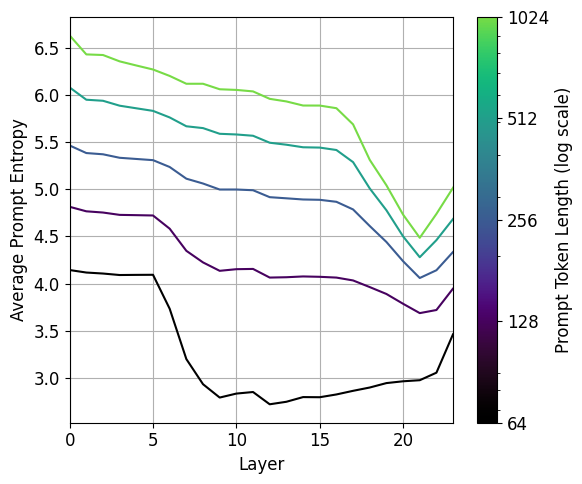

In [14]:
import matplotlib

results = pickle.load(open(f'small_results/pythia_random_of_differing_lengths.pkl', 'rb'))
results.pop(2048)

fig, ax = plt.subplots(figsize=(6, 5))
lengths = list(results.keys())
log_lengths = np.log2(lengths)  # Convert lengths to log scale
colors = cmr.lavender(np.linspace(0, 1, len(lengths)))
cmap = cmr.lavender
norm =  matplotlib.colors.LogNorm(vmin=min(lengths), vmax=max(lengths))

normalization = 'raw'

for idx, (length, entropy) in enumerate(results.items()):
    ax.plot(entropy[normalization].mean(axis=0), color=colors[idx], label=f'Length: {length}')

ax.set_xlabel("Layer")
if normalization == 'maxEntropy':
    ax.set_ylabel("Average Normalized Prompt Entropy")
    ax.set_ylim(0, 1)
else:
    ax.set_ylabel("Average Prompt Entropy")
ax.set_xlim(0, 23)
ax.grid()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Prompt Token Length (log scale)')
cbar.set_ticks(lengths)
cbar.set_ticklabels(lengths)
plt.tight_layout()
plt.savefig(f'figures/pythia_random_of_differing_lengths_{normalization}.pdf')

# Behavior of matrix-based entropy

In [2]:
def get_eigenvalues_with_power_law(N, beta):
    """
    Make a matrix with eigenvalues that follow a power law distribution,
    same eigenvalues as idendity
    """
    eigenvalues = np.linspace(1, N, N)**-beta
    eigenvalues /= eigenvalues.sum()

    # the formula for the i-th largest eigenvalue is i**-beta
    return eigenvalues

def calculate_number_of_principal_components_to_preserve_variance(eigenvalues, threshold=0.95):
    """
    Calculate the number of principal components to preserve 95% of the variance
    """
    total_variance = eigenvalues.sum()

    variance = 0
    for i, eigenvalue in enumerate(eigenvalues):
        variance += eigenvalue
        if variance >= threshold * total_variance:
            return i + 1

    return len(eigenvalues)

def get_entropy_from_eigenvalues(eigenvalues, alpha=1):
    """
    Calculate the entropy of the eigenvalues
    """
    if alpha == 1:
        entropy = -np.sum(eigenvalues * np.log(eigenvalues))
    else:
        entropy = (1 / (1 - alpha)) * np.log(np.sum(eigenvalues**alpha))

    return entropy / np.log(len(eigenvalues))

def get_logdet_entropy_from_eigenvalues(eigenvalues):
    """
    Calculate the entropy of the eigenvalues using the log determinant
    """
    N = len(eigenvalues)
    logdet = np.sum(np.log(1+eigenvalues))
    logdet -= np.log(2)
    return logdet


[0.30188590475686417, 0.3018364521564717, 0.30165372739644447, 0.3012657985167685, 0.3005649019565084, 0.29939676035801777, 0.2975541255992191, 0.2947814747137939, 0.29079809820303415, 0.28534218454278604, 0.27822852292232136, 0.26940180783419787, 0.25896437065753164, 0.24716605973540062, 0.23436032932059614, 0.2209438023033099, 0.20729933411156498, 0.19375599065523408, 0.1805696746654758, 0.16792092372783496, 0.15592349177774478, 0.14463769732206477, 0.13408434760237797, 0.12425697473190889, 0.11513154350045862, 0.10667362505730871, 0.09884341387398687, 0.09159907293337854, 0.08489886126911583, 0.07870241442471027, 0.07297145712272546, 0.06767014785629977, 0.062765192871446, 0.05822582137508536, 0.05402368176524941, 0.050132696879904404, 0.04652890178318836, 0.04319027818625365, 0.04009659358123374, 0.03722924939411265, 0.03457114014751661, 0.032106524243103896, 0.02982090618053912, 0.027700929603391544, 0.02573428035848213, 0.023909598684415556, 0.022216399649939045, 0.02064500100899

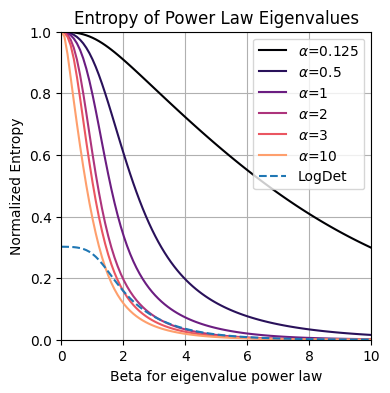

In [65]:
import matplotlib.pyplot as plt
import numpy as np
alphas = [1/8, 1/2, 1, 2, 3, 10]
betas = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('magma')

colors = cmap(np.linspace(0, 0.8, len(alphas)))  # Changed start from 0 to 0.2 to make endpoint darker
for alpha, color in zip(alphas, colors):
    eigenvalue_sets = [get_eigenvalues_with_power_law(100, beta) for beta in betas]
    entropies = [get_entropy_from_eigenvalues(eigenvalues, alpha) for eigenvalues in eigenvalue_sets]
    ax.plot(betas, entropies, label=f'$\\alpha$={alpha}', color=color)

logdet_entropies = [get_logdet_entropy_from_eigenvalues(eigenvalues) for eigenvalues in eigenvalue_sets]
ax.plot(betas, logdet_entropies, label='LogDet', linestyle='--')
print(logdet_entropies)
ax.set_title("Entropy of Power Law Eigenvalues")
ax.set_xlabel("Beta for eigenvalue power law")
ax.set_ylabel("Normalized Entropy")
ax.grid()
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)

plt.legend()
plt.savefig('figures/power_law_entropy.pdf')

# Metrics across training

### Single plots

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

models = ["Pythia"]
metrics = ["sentence-entropy", 'curvature', "infonce", "lidar", 'dime']
pythia_revision_steps = [1, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]
revisions = ['main'] + [f"step{step}" for step in pythia_revision_steps]

results = load_results_for_model_and_revisions("Pythia", "410m", revisions, metrics)

model_name_to_label = {
    "Pythia": "Pythia",
}
metric_name_to_label = {
    "sentence-entropy": "Prompt Entropy",
    "dataset-entropy": "Batch Entropy",
    "infonce": "InfoNCE",
    "lidar": "LiDAR",
    "dime": "DiME",
    "curvature": "Curvature",
}

metric_name_to_normalization = {
    "curvature": "raw",
    "dime": "raw",
    "sentence-entropy": "maxEntropy",
    "dataset-entropy": "raw",
    "infonce": "raw",
    "lidar": "raw"
}

# Add a new metric for DiME normalized by dataset entropy
metrics.append("dime-normalized")
metric_name_to_label["dime-normalized"] = "DiME divided by Prompt Entropy"
metric_name_to_normalization["dime-normalized"] = "raw"
print(results.keys())
for revision in revisions:
    dime_results = results[(revision, "dime")]["raw"]
    dataset_entropy_results = results[(revision, "sentence-entropy")]["maxEntropy"]
    if len(dime_results) != len(dataset_entropy_results):
        raise ValueError(f"Length mismatch for revision {revision}: DiME ({len(dime_results)}) vs Dataset Entropy ({len(dataset_entropy_results)})")
    normalized_results = [dime / entropy if entropy != 0 else 0 for dime, entropy in zip(dime_results, dataset_entropy_results)]
    results[(revision, "dime-normalized")] = {"raw": normalized_results}

# Split metrics into two rows
top_metrics = metrics[:3]
bottom_metrics = metrics[3:]
for evaluation_metric in metrics:
    # Adjust figure size for InfoNCE plot to accommodate colorbar
    if True or evaluation_metric == "infonce":
        fig, ax = plt.subplots(figsize=(6.5, 5))  # Wider figure for InfoNCE
    else:
        fig, ax = plt.subplots(figsize=(5, 5))
    
    if results:
        cmap = plt.cm.Greens
        norm = colors.LogNorm(vmin=min(pythia_revision_steps), vmax=max(pythia_revision_steps))

        for revision in revisions:
            metric_results = results[(revision, evaluation_metric)]
            metric_results = metric_results[metric_name_to_normalization[evaluation_metric]]
            
            if revision == 'main':
                step = 143000
            else:
                step = int(revision.split('step')[1])
            if step < 10:
                color = cmap(norm(step) + 0.2)
            else:
                color = cmap(norm(step))

            ax.plot(range(len(metric_results)), metric_results, marker='o', color=color, label=f'Step {step}')
    else:
        ax.text(0.5, 0.5, 'Missing data', ha='center', va='center', fontsize=12, color='red')

    ax.set_xlabel('Layer')
    ax.set_ylabel(metric_name_to_label[evaluation_metric])
    ax.yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))  # Reduce number of y-axis ticks to 4

    ax.grid(True)
    ax.set_xlim(0, 24)
    if True or evaluation_metric == "infonce":
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label('Training Step')
    
    plt.savefig(f"figures/metrics_at_pythia_checkpoints_{evaluation_metric}.pdf")
    plt.close()

dict_keys([('main', 'sentence-entropy'), ('main', 'curvature'), ('main', 'infonce'), ('main', 'lidar'), ('main', 'dime'), ('step1', 'sentence-entropy'), ('step1', 'curvature'), ('step1', 'infonce'), ('step1', 'lidar'), ('step1', 'dime'), ('step1000', 'sentence-entropy'), ('step1000', 'curvature'), ('step1000', 'infonce'), ('step1000', 'lidar'), ('step1000', 'dime'), ('step2000', 'sentence-entropy'), ('step2000', 'curvature'), ('step2000', 'infonce'), ('step2000', 'lidar'), ('step2000', 'dime'), ('step4000', 'sentence-entropy'), ('step4000', 'curvature'), ('step4000', 'infonce'), ('step4000', 'lidar'), ('step4000', 'dime'), ('step8000', 'sentence-entropy'), ('step8000', 'curvature'), ('step8000', 'infonce'), ('step8000', 'lidar'), ('step8000', 'dime'), ('step16000', 'sentence-entropy'), ('step16000', 'curvature'), ('step16000', 'infonce'), ('step16000', 'lidar'), ('step16000', 'dime'), ('step32000', 'sentence-entropy'), ('step32000', 'curvature'), ('step32000', 'infonce'), ('step32000',

dict_keys([('main', 'sentence-entropy'), ('main', 'curvature'), ('main', 'infonce'), ('main', 'lidar'), ('main', 'dime'), ('step1', 'sentence-entropy'), ('step1', 'curvature'), ('step1', 'infonce'), ('step1', 'lidar'), ('step1', 'dime'), ('step1000', 'sentence-entropy'), ('step1000', 'curvature'), ('step1000', 'infonce'), ('step1000', 'lidar'), ('step1000', 'dime'), ('step2000', 'sentence-entropy'), ('step2000', 'curvature'), ('step2000', 'infonce'), ('step2000', 'lidar'), ('step2000', 'dime'), ('step4000', 'sentence-entropy'), ('step4000', 'curvature'), ('step4000', 'infonce'), ('step4000', 'lidar'), ('step4000', 'dime'), ('step8000', 'sentence-entropy'), ('step8000', 'curvature'), ('step8000', 'infonce'), ('step8000', 'lidar'), ('step8000', 'dime'), ('step16000', 'sentence-entropy'), ('step16000', 'curvature'), ('step16000', 'infonce'), ('step16000', 'lidar'), ('step16000', 'dime'), ('step32000', 'sentence-entropy'), ('step32000', 'curvature'), ('step32000', 'infonce'), ('step32000',

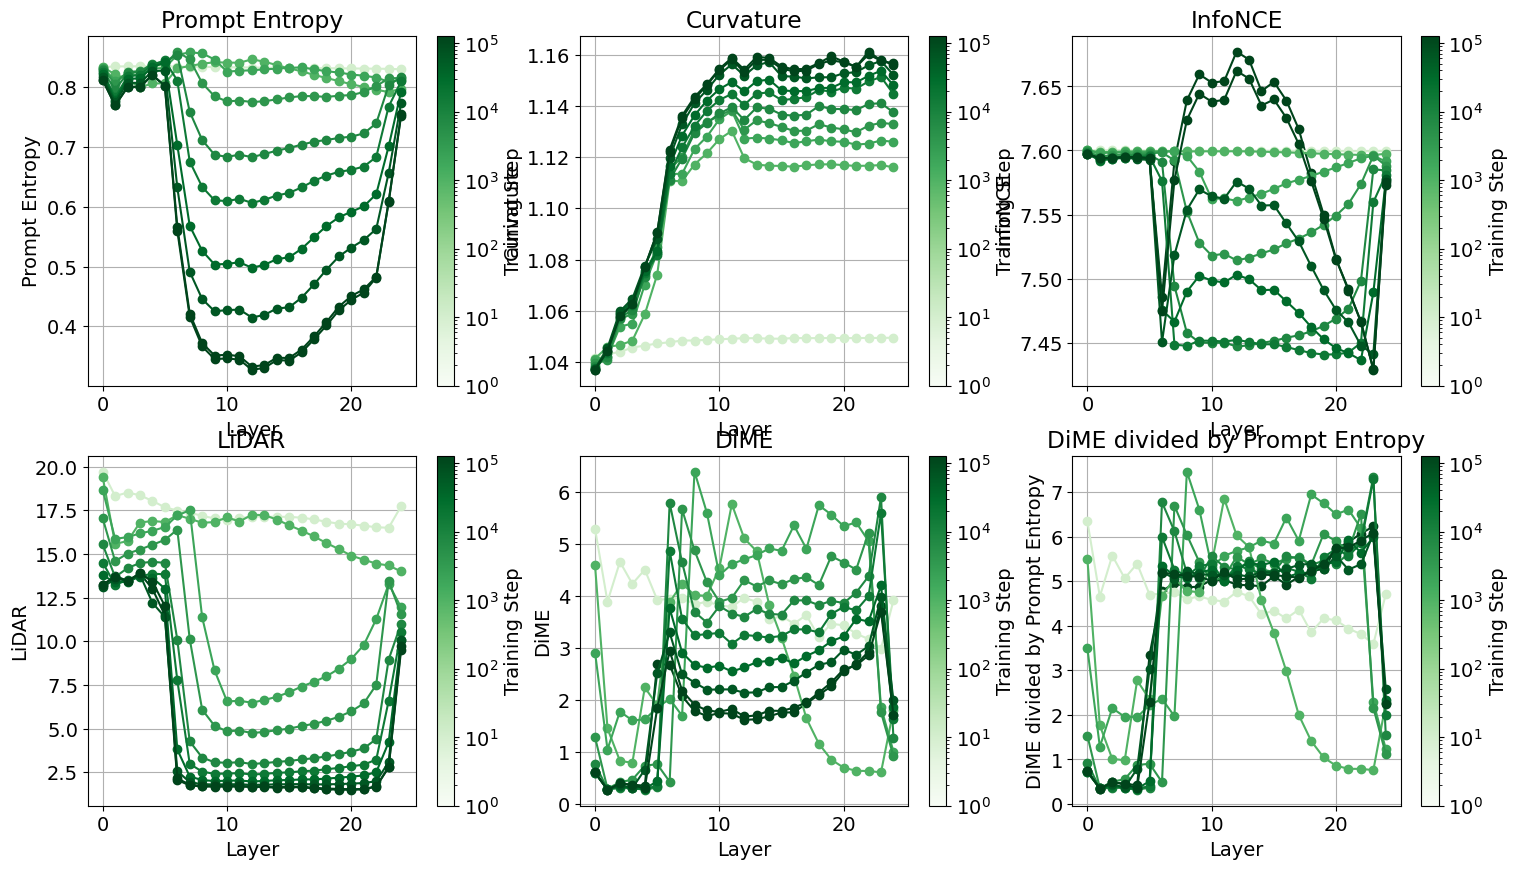

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

models = ["Pythia"]
metrics = ["sentence-entropy", 'curvature', "infonce", "lidar", 'dime']
pythia_revision_steps = [1, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]
revisions = ['main'] + [f"step{step}" for step in pythia_revision_steps]

results = load_results_for_model_and_revisions("Pythia", "410m", revisions, metrics)

model_name_to_label = {
    "Pythia": "Pythia",
}
metric_name_to_label = {
    "sentence-entropy": "Prompt Entropy",
    "dataset-entropy": "Batch Entropy",
    "infonce": "InfoNCE",
    "lidar": "LiDAR",
    "dime": "DiME",
    "curvature": "Curvature",
}

metric_name_to_normalization = {
    "curvature": "raw",
    "dime": "raw",
    "sentence-entropy": "maxEntropy",
    "dataset-entropy": "raw",
    "infonce": "raw",
    "lidar": "raw"
}

# Add a new metric for DiME normalized by dataset entropy
metrics.append("dime-normalized")
metric_name_to_label["dime-normalized"] = "DiME divided by Prompt Entropy"
metric_name_to_normalization["dime-normalized"] = "raw"
print(results.keys())
for revision in revisions:
    dime_results = results[(revision, "dime")]["raw"]
    dataset_entropy_results = results[(revision, "sentence-entropy")]["maxEntropy"]
    if len(dime_results) != len(dataset_entropy_results):
        raise ValueError(f"Length mismatch for revision {revision}: DiME ({len(dime_results)}) vs Dataset Entropy ({len(dataset_entropy_results)})")
    normalized_results = [dime / entropy if entropy != 0 else 0 for dime, entropy in zip(dime_results, dataset_entropy_results)]
    results[(revision, "dime-normalized")] = {"raw": normalized_results}

# Split metrics into two rows
top_metrics = metrics[:3]
bottom_metrics = metrics[3:]

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

for row, row_metrics in enumerate([top_metrics, bottom_metrics]):
    for col, evaluation_metric in enumerate(row_metrics):
        ax = axs[row, col]
        
        if results:
            cmap = plt.cm.Greens
            norm = colors.LogNorm(vmin=min(pythia_revision_steps), vmax=max(pythia_revision_steps))

            for revision in revisions:
                metric_results = results[(revision, evaluation_metric)]
                metric_results = metric_results[metric_name_to_normalization[evaluation_metric]]
                
                if revision == 'main':
                    step = 143000
                else:
                    step = int(revision.split('step')[1])
                if step < 10:
                    color = cmap(norm(step) + 0.2)
                else:
                    color = cmap(norm(step))

                ax.plot(range(len(metric_results)), metric_results, marker='o', color=color, label=f'Step {step}')
        else:
            ax.text(0.5, 0.5, 'Missing data', ha='center', va='center', fontsize=12, color='red')

        ax.set_xlabel('Layer')
        ax.set_ylabel(metric_name_to_label[evaluation_metric])

        ax.grid(True)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label('Training Step')
        
        ax.set_title(metric_name_to_label[evaluation_metric])
        

plt.savefig(f"figures/metrics_at_pythia_checkpoints.pdf")
plt.show()


# Metrics across architectures

### Single Figures

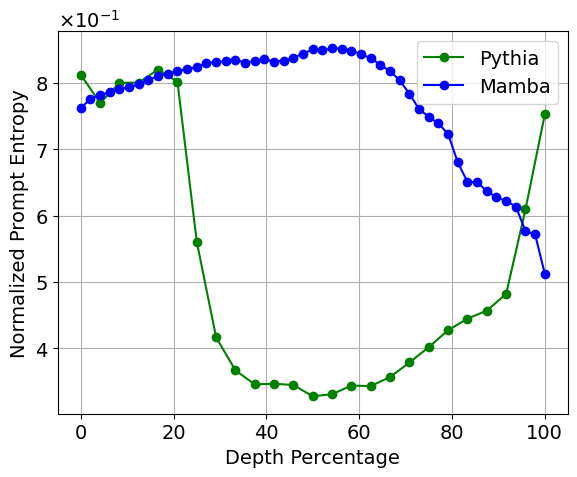

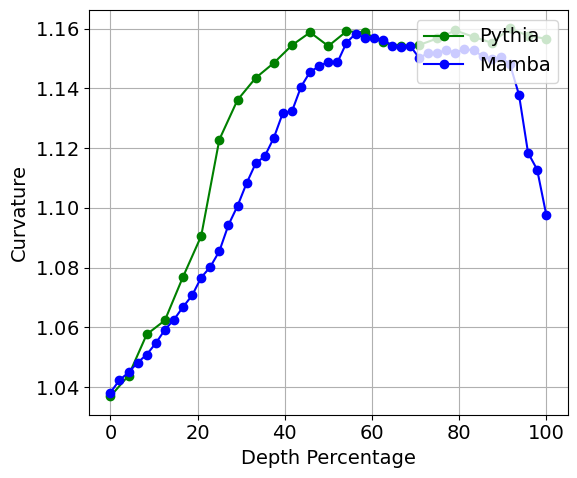

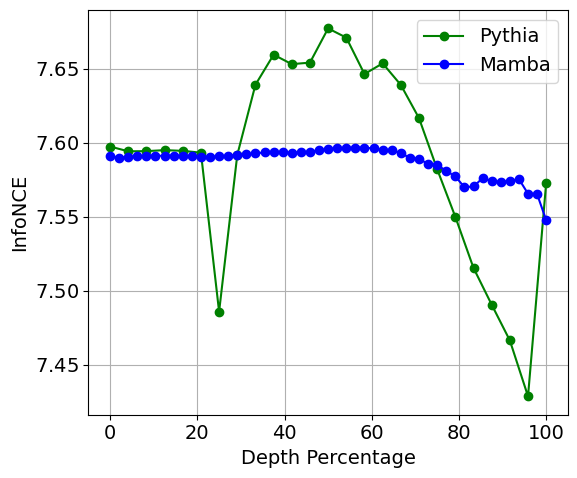

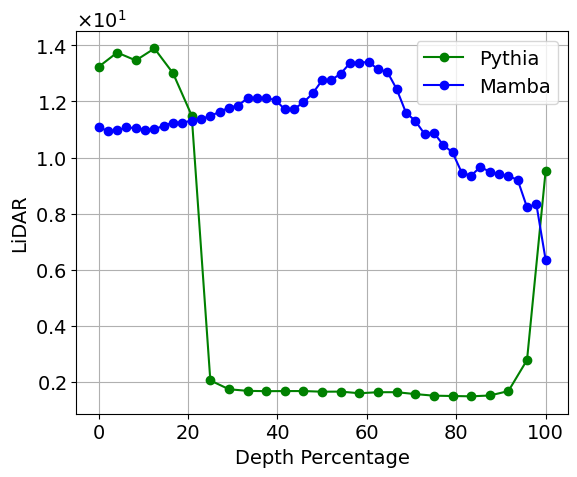

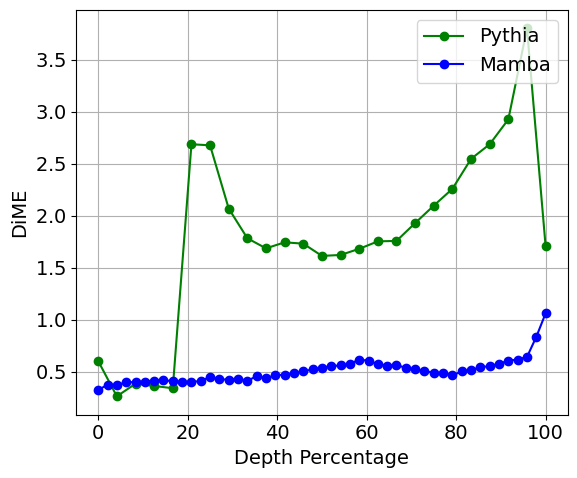

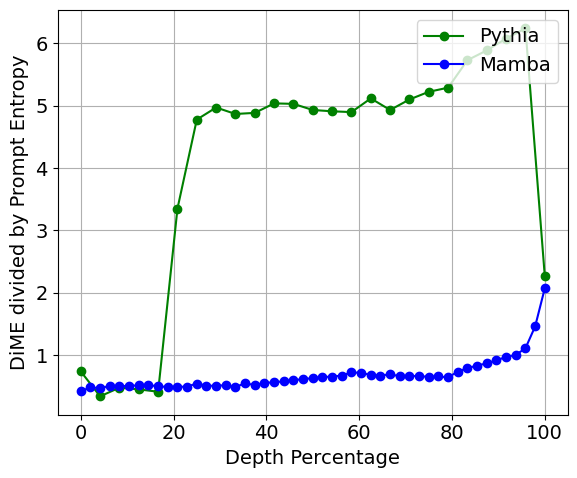

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

metrics = ["sentence-entropy", 'curvature', "infonce", "lidar", 'dime']
model_families = ["Pythia", "mamba"]

family_to_model_size = {
    "Pythia": "410m",
    "mamba": "370m",
}

family_to_results = {}
for model_family in model_families:
    family_to_results[model_family] = load_results_for_model_and_revisions(model_family, family_to_model_size[model_family], ["main"], metrics)

metric_name_to_label = {
    "sentence-entropy": "Normalized Prompt Entropy",
    "dataset-entropy": "Batch Entropy",
    "infonce": "InfoNCE",
    "lidar": "LiDAR",
    "dime": "DiME",
    "curvature": "Curvature",
}

metric_name_to_normalization = {
    "curvature": "raw",
    "dime": "raw",
    "sentence-entropy": "maxEntropy",
    "dataset-entropy": "raw",
    "infonce": "raw",
    "lidar": "raw"
}

# Add a new metric for DiME normalized by dataset entropy
metrics.append("dime-normalized")
metric_name_to_label["dime-normalized"] = "DiME divided by Prompt Entropy"
metric_name_to_normalization["dime-normalized"] = "raw"

for model_family in model_families:
    results = family_to_results[model_family]
    for revision in ["main"]:
        dime_results = results[(revision, "dime")]["raw"]
        dataset_entropy_results = results[(revision, "sentence-entropy")]["maxEntropy"]
        if len(dime_results) != len(dataset_entropy_results):
            raise ValueError(f"Length mismatch for {model_family} revision {revision}: DiME ({len(dime_results)}) vs Dataset Entropy ({len(dataset_entropy_results)})")
        normalized_results = [dime / entropy if entropy != 0 else 0 for dime, entropy in zip(dime_results, dataset_entropy_results)]
        results[(revision, "dime-normalized")] = {"raw": normalized_results}

for evaluation_metric in metrics:
    plt.figure(figsize=(6, 5))
    
    for model_family in model_families:
        results = family_to_results[model_family]
        metric_results = results[("main", evaluation_metric)]
        metric_results = metric_results[metric_name_to_normalization[evaluation_metric]]
        depth_percentage = np.linspace(0, 100, len(metric_results))
        color = 'green' if model_family == "Pythia" else 'blue'
        plt.plot(depth_percentage, metric_results, marker='o', color=color, label=model_family.capitalize())

    plt.xlabel('Depth Percentage')
    plt.ylabel(metric_name_to_label[evaluation_metric])
    #plt.title(metric_name_to_label[evaluation_metric])
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    plt.tight_layout()
    plt.savefig(f"figures/metrics_comparison_pythia_mamba_llama_{evaluation_metric}.pdf")
    plt.show()
    plt.close()

### All Figures

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

metrics = ["sentence-entropy", 'curvature', "infonce", "lidar", 'dime']
model_families = ["Pythia", "mamba"]

family_to_model_size = {
    "Pythia": "410m",
    "mamba": "370m",
}

family_to_results = {}
for model_family in model_families:
    family_to_results[model_family] = load_results_for_model_and_revisions(model_family, family_to_model_size[model_family], ["main"], metrics)

metric_name_to_label = {
    "sentence-entropy": "Normalized Prompt Entropy",
    "dataset-entropy": "Batch Entropy",
    "infonce": "InfoNCE",
    "lidar": "LiDAR",
    "dime": "DiME",
    "curvature": "Curvature",
}

metric_name_to_normalization = {
    "curvature": "raw",
    "dime": "raw",
    "sentence-entropy": "maxEntropy",
    "dataset-entropy": "raw",
    "infonce": "raw",
    "lidar": "raw"
}

# Add a new metric for DiME normalized by dataset entropy
metrics.append("dime-normalized")
metric_name_to_label["dime-normalized"] = "DiME divided by Prompt Entropy"
metric_name_to_normalization["dime-normalized"] = "raw"

for model_family in model_families:
    results = family_to_results[model_family]
    for revision in ["main"]:
        dime_results = results[(revision, "dime")]["raw"]
        dataset_entropy_results = results[(revision, "sentence-entropy")]["maxEntropy"]
        if len(dime_results) != len(dataset_entropy_results):
            raise ValueError(f"Length mismatch for {model_family} revision {revision}: DiME ({len(dime_results)}) vs Dataset Entropy ({len(dataset_entropy_results)})")
        normalized_results = [dime / entropy if entropy != 0 else 0 for dime, entropy in zip(dime_results, dataset_entropy_results)]
        results[(revision, "dime-normalized")] = {"raw": normalized_results}

# Split metrics into two rows
top_metrics = metrics[:3]
bottom_metrics = metrics[3:]

fig, axs = plt.subplots(2, 3, figsize=(16, 10))

for row, row_metrics in enumerate([top_metrics, bottom_metrics]):
    for col, evaluation_metric in enumerate(row_metrics):
        ax = axs[row, col]
        
        for model_family in model_families:
            results = family_to_results[model_family]
            metric_results = results[("main", evaluation_metric)]
            metric_results = metric_results[metric_name_to_normalization[evaluation_metric]]
            depth_percentage = np.linspace(0, 100, len(metric_results))
            color = 'green' if model_family == "Pythia" else 'blue'
            ax.plot(depth_percentage, metric_results, marker='o', color=color, label=model_family)

        ax.set_xlabel('Depth Percentage')
        ax.set_ylabel(metric_name_to_label[evaluation_metric])
        ax.set_title(metric_name_to_label[evaluation_metric])
        
        ax.grid(True)
        if row == 0 and col == 0:
            ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f"figures/metrics_comparison_pythia_mamba_llama.pdf")
plt.show()


# Correlation between Metrics and Downstream Performance

In [4]:
all_results = load_all_results(should_normalize_scores_across_models=False, base_path="results")

In [5]:
# find number of models
num_total_models = 0
num_base_models = 0
for model_family in all_results.keys():
    for model_size in all_results[model_family].keys():
        num_base_models += 1
        for revision in all_results[model_family][model_size].keys():
            num_total_models += 1
print("Num. models: ", num_base_models)
print("Num. models (including Pythia ckpts): ", num_total_models)


# find number of layers we tested
num_layers_tested = 0
for model_family in all_results.keys():
    for model_size in all_results[model_family].keys():
        for revision in all_results[model_family][model_size].keys():
            for layer in all_results[model_family][model_size][revision].keys():
                if layer.startswith('layer_'):
                    num_layers_tested += 1
print("Num. layers tested: ", num_layers_tested)

# find number of datasets we tested across all layers
num_benchmarks_tested = 0
for model_family in all_results.keys():
    for model_size in all_results[model_family].keys():
        for revision in all_results[model_family][model_size].keys():
            for layer in all_results[model_family][model_size][revision].keys():
                if layer.startswith('layer_'):
                    for task_name in all_results[model_family][model_size][revision][layer].keys():
                        num_benchmarks_tested += 1
print("Num. benchmarks ran: ", num_benchmarks_tested)


Num. models:  23
Num. models (including Pythia ckpts):  41
Num. layers tested:  940
Num. benchmarks ran:  18568


0.3699075982087302 0.49057258353468114 0.0957659549231063 0.39926347722678523


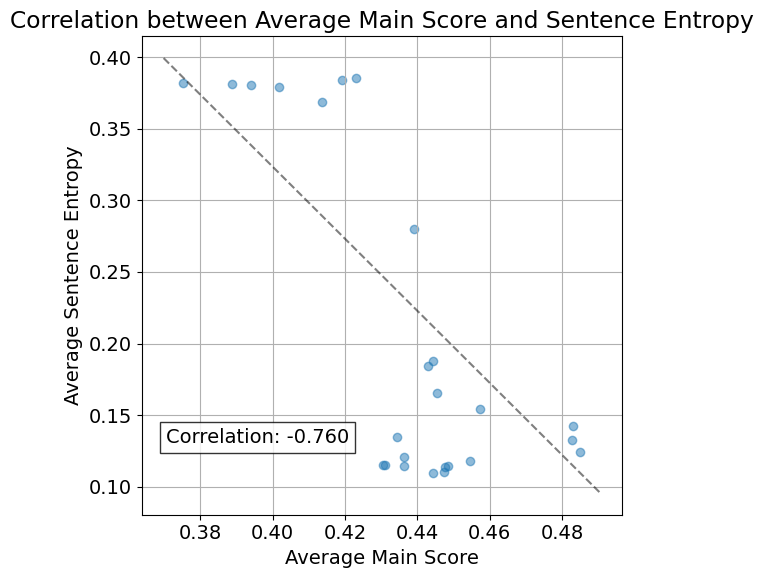

In [7]:
# make a pyplot depicting main score on the x axis and entropy on the y axis

# Collect data points for scatter plot
x_values = []  # Main scores
y_values = []  # Entropy values

model_family = 'Pythia'
model_sizes = ['410m']
plot_all_layers = True # Set to True to plot every layer, False to plot nth highest layer
n_from_top = 1 # 0 means highest layer, 1 means second highest, etc.

for model_size in model_sizes:
    # Find target layer number if needed
    if not plot_all_layers:
        # Get all layer numbers
        layer_nums = []
        for layer in all_results[model_family][model_size]['main'].keys():
            if layer.startswith('layer_'):
                layer_nums.append(int(layer.split('_')[1]))
        
        # Sort descending and get nth highest
        layer_nums.sort(reverse=True)
        target_layer = layer_nums[n_from_top] if layer_nums else -1
                
    for layer in all_results[model_family][model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        # Skip if we only want nth highest layer and this isn't it
        if not plot_all_layers:
            layer_num = int(layer.split('_')[1])
            if layer_num != target_layer:
                continue
            
        layer_results = all_results[model_family][model_size]['main'][layer]
        
        # Calculate average main score for this layer
        main_scores = []
        entropies = []
        for task_name, task_results in layer_results.items():
            if 'main_score' in task_results and 'dime' in task_results and 'entropy_prompt' in task_results:
                main_scores.append(task_results['main_score'])
                entropies.append(task_results['entropy_prompt']['logD'])
                
        if main_scores:
            x_values.append(np.mean(main_scores))
            y_values.append(np.mean(entropies))

# Create square scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_values, y_values, alpha=0.5)
plt.xlabel('Average Main Score')
plt.ylabel('Average Sentence Entropy')
plt.title('Correlation between Average Main Score and Sentence Entropy')
plt.grid(True)

# Calculate and display correlation coefficient
correlation = np.corrcoef(x_values, y_values)[0,1]
plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

# Add negative diagonal line
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
print(x_min, x_max, y_min, y_max)
plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

plt.tight_layout()
#plt.savefig("figures/metric_correlation.pdf")
plt.show()


-0.051642811332591784 0.8844538984192789 0.04669828031395919 0.5423196636748157


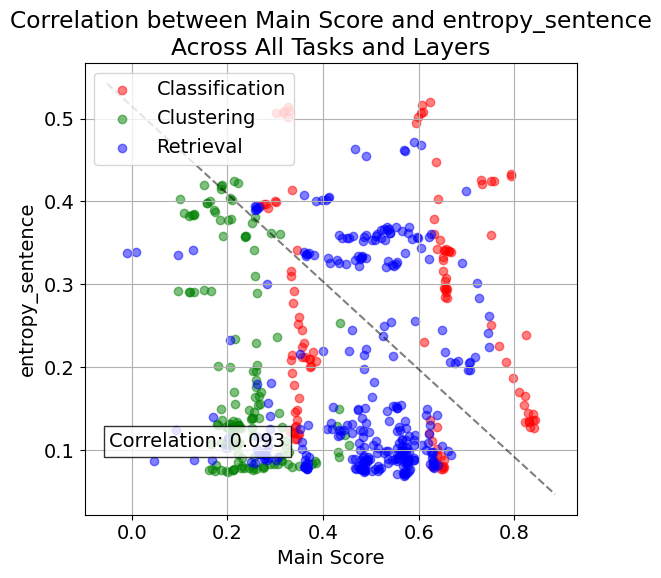

In [18]:
# make a pyplot depicting main score on the x axis and entropy on the y axis

# Collect data points for scatter plot
x_values_class = []  # Main scores for classification tasks
y_values_class = []  # Entropy values for classification tasks
x_values_clust = []  # Main scores for clustering tasks 
y_values_clust = []  # Entropy values for clustering tasks
x_values_retrieval = []  # Main scores for retrieval tasks
y_values_retrieval = []  # Entropy values for retrieval tasks

model_family = 'Pythia'
model_sizes = ['410m']
plot_all_layers = True # Set to True to plot every layer, False to plot nth highest layer
n_from_top = 1 # 0 means highest layer, 1 means second highest, etc.

for model_size in model_sizes:
    # Find target layer number if needed
    if not plot_all_layers:
        # Get all layer numbers
        layer_nums = []
        for layer in all_results[model_family][model_size]['main'].keys():
            if layer.startswith('layer_'):
                layer_nums.append(int(layer.split('_')[1]))
        
        # Sort descending and get nth highest
        layer_nums.sort(reverse=True)
        target_layer = layer_nums[n_from_top] if layer_nums else -1
                
    for layer in all_results[model_family][model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        # Skip if we only want nth highest layer and this isn't it
        if not plot_all_layers:
            layer_num = int(layer.split('_')[1])
            if layer_num != target_layer:
                continue
            
        layer_results = all_results[model_family][model_size]['main'][layer]
        
        # Get scores for each task in this layer
        for task_name, task_results in layer_results.items():
            if 'main_score' in task_results and 'dime' in task_results and 'entropy_sentence' in task_results:
                if 'Classification' in task_name:
                    x_values_class.append(task_results['main_score'])
                    y_values_class.append(task_results['entropy_sentence']['logD'])
                elif 'Clustering' in task_name:
                    x_values_clust.append(task_results['main_score'])
                    y_values_clust.append(task_results['entropy_sentence']['logD'])
                else:
                    x_values_retrieval.append(task_results['main_score'])
                    y_values_retrieval.append(task_results['entropy_sentence']['logD'])

# Create square scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_values_class, y_values_class, alpha=0.5, c='red', label='Classification')
plt.scatter(x_values_clust, y_values_clust, alpha=0.5, c='green', label='Clustering')
plt.scatter(x_values_retrieval, y_values_retrieval, alpha=0.5, c='blue', label='Retrieval')
plt.xlabel('Main Score')
plt.ylabel('entropy_sentence')
plt.title('Correlation between Main Score and entropy_sentence\nAcross All Tasks and Layers')
plt.grid(True)
plt.legend()

# Calculate and display correlation coefficient for all points combined
x_values = x_values_class + x_values_clust
y_values = y_values_class + y_values_clust
correlation = np.corrcoef(x_values, y_values)[0,1]
plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

# Add negative diagonal line
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
print(x_min, x_max, y_min, y_max)
plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

plt.tight_layout()
#plt.savefig("figures/metric_correlation.pdf")
plt.show()


0.3699075982087302 0.49057258353468114 -0.034553286563277406 0.3650441830981004


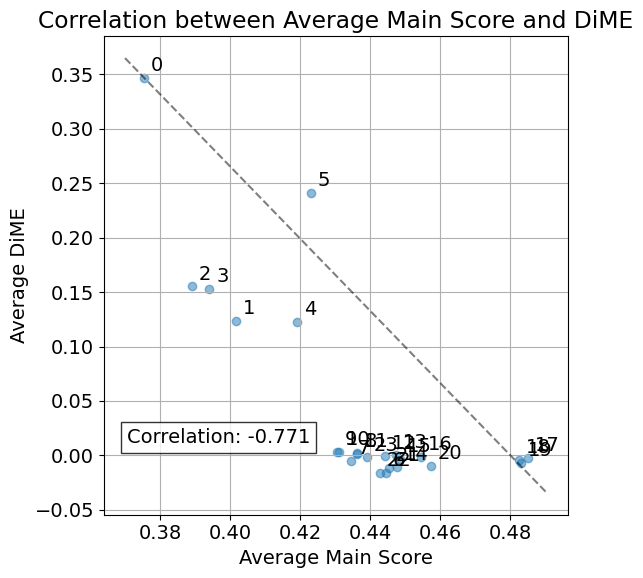

In [6]:
# make a pyplot depicting main score on the x axis and entropy on the y axis

# Collect data points for scatter plot
x_values = []  # Main scores
y_values = []  # Entropy values
layer_numbers = []  # Layer numbers for annotations

model_family = 'Pythia'
model_sizes = ['410m']
plot_all_layers = True # Set to True to plot every layer, False to plot nth highest layer
n_from_top = 1 # 0 means highest layer, 1 means second highest, etc.

for model_size in model_sizes:
    # Find target layer number if needed
    if not plot_all_layers:
        # Get all layer numbers
        layer_nums = []
        for layer in all_results[model_family][model_size]['main'].keys():
            if layer.startswith('layer_'):
                layer_nums.append(int(layer.split('_')[1]))
        
        # Sort descending and get nth highest
        layer_nums.sort(reverse=True)
        target_layer = layer_nums[n_from_top] if layer_nums else -1
                
    for layer in all_results[model_family][model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        # Skip if we only want nth highest layer and this isn't it
        if not plot_all_layers:
            layer_num = int(layer.split('_')[1])
            if layer_num != target_layer:
                continue
            
        layer_results = all_results[model_family][model_size]['main'][layer]
        layer_num = int(layer.split('_')[1])
        
        # Calculate average main score for this layer
        main_scores = []
        entropies = []
        for task_name, task_results in layer_results.items():
            if 'main_score' in task_results and 'dime' in task_results and 'entropy_sentence' in task_results:
                main_scores.append(task_results['main_score'])
                entropies.append(task_results['dime']['logD'] / task_results['entropy_sentence']['logD'])
                
        if main_scores:
            x_values.append(np.mean(main_scores))
            y_values.append(np.mean(entropies))
            layer_numbers.append(layer_num)

# Create square scatter plot
plt.figure(figsize=(6, 6))
scatter = plt.scatter(x_values, y_values, alpha=0.5)

# Add layer number annotations
for i, layer_num in enumerate(layer_numbers):
    plt.annotate(str(layer_num), (x_values[i], y_values[i]), 
                xytext=(5, 5), textcoords='offset points')

plt.xlabel('Average Main Score')
plt.ylabel('Average DiME')
plt.title('Correlation between Average Main Score and DiME')
plt.grid(True)

# Calculate and display correlation coefficient
correlation = np.corrcoef(x_values, y_values)[0,1]
plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

# Add negative diagonal line
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
print(x_min, x_max, y_min, y_max)
plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

plt.tight_layout()
#plt.savefig("figures/metric_correlation.pdf")
plt.show()


0.19855238357140842 0.8485875319595823 -0.0054937928267719816 0.0034467679691758566


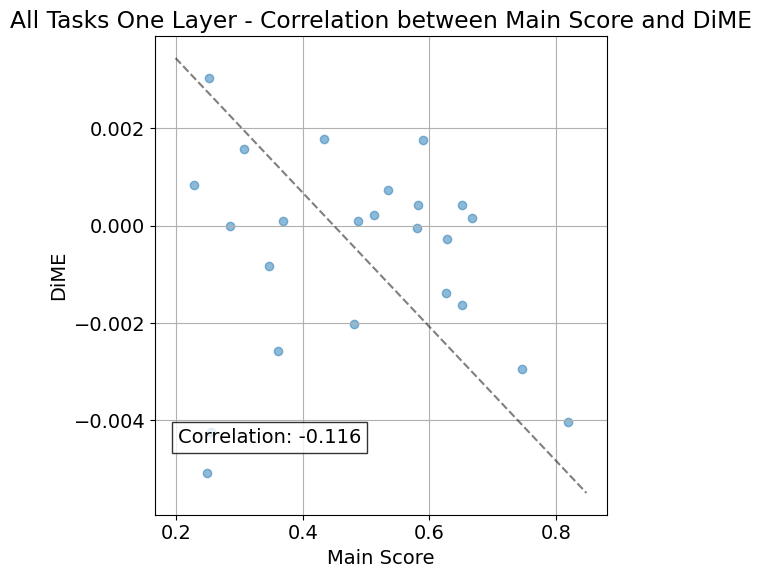

In [12]:
# make a pyplot depicting main score on the x axis and entropy on the y axis

# Collect data points for scatter plot
x_values = []  # Main scores
y_values = []  # Entropy values

model_family = 'Pythia'
model_sizes = ['410m']
plot_all_layers = True # Set to True to plot every layer, False to plot nth highest layer

for model_size in model_sizes:
    # Find target layer number if needed
    if not plot_all_layers:
        # Get all layer numbers
        layer_nums = []
        for layer in all_results[model_family][model_size]['main'].keys():
            if layer.startswith('layer_17'):
                layer_nums.append(int(layer.split('_')[1]))
        
        # Sort descending and get nth highest
        layer_nums.sort(reverse=True)
        target_layer = layer_nums[n_from_top] if layer_nums else -1
                
    for layer in all_results[model_family][model_size]['main'].keys():
        if not layer.startswith('layer_17'):
            continue
            
        # Skip if we only want nth highest layer and this isn't it
        if not plot_all_layers:
            layer_num = int(layer.split('_')[1])
            if layer_num != target_layer:
                continue
            
        layer_results = all_results[model_family][model_size]['main'][layer]
        
        # Get main score and entropy for each task
        for task_name, task_results in layer_results.items():
            if 'main_score' in task_results and 'dime' in task_results and 'entropy_sentence' in task_results:
                x_values.append(task_results['main_score'])
                #y_values.append(task_results['dime']['logD'] / task_results['entropy_sentence']['logD'])
                y_values.append(task_results['dime']['logD'])

# Create square scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_values, y_values, alpha=0.5)
plt.xlabel('Main Score')
plt.ylabel('DiME')
plt.title('All Tasks One Layer - Correlation between Main Score and DiME')
plt.grid(True)

# Calculate and display correlation coefficient
correlation = np.corrcoef(x_values, y_values)[0,1]
plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

# Add negative diagonal line
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()
print(x_min, x_max, y_min, y_max)
plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

plt.tight_layout()
#plt.savefig("figures/metric_correlation.pdf")
plt.show()


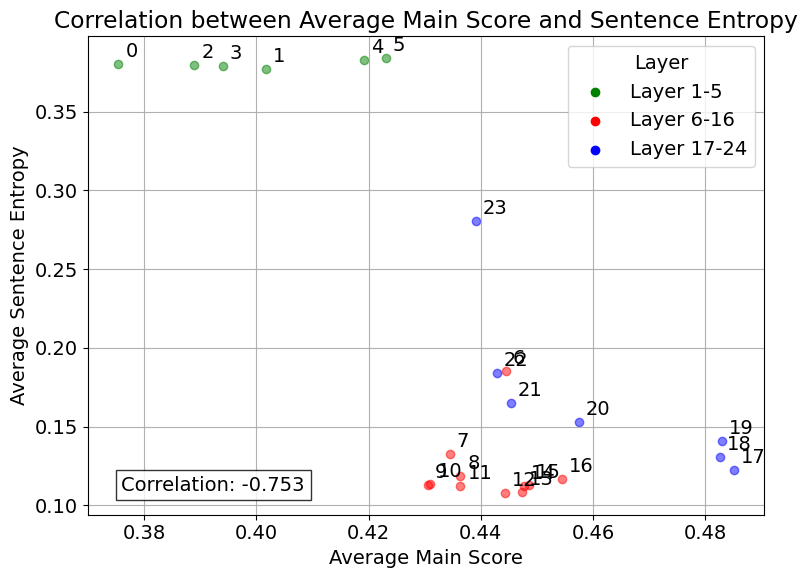

In [4]:
# make a pyplot depicting main score on the x axis and entropy on the y axis

# Collect data points for scatter plot
x_values = []  # Main scores
y_values = []  # Entropy values
layer_numbers = []  # To track which layer each point comes from

model_family = 'Pythia'
model_sizes = ['410m']
plot_all_layers = True # Set to True to plot every layer, False to plot nth highest layer
n_from_top = 1 # 0 means highest layer, 1 means second highest, etc.

for model_size in model_sizes:
    # Find target layer number if needed
    if not plot_all_layers:
        # Get all layer numbers
        layer_nums = []
        for layer in all_results[model_family][model_size]['main'].keys():
            if layer.startswith('layer_'):
                layer_nums.append(int(layer.split('_')[1]))
        
        # Sort descending and get nth highest
        layer_nums.sort(reverse=True)
        target_layer = layer_nums[n_from_top] if layer_nums else -1
                
    for layer in all_results[model_family][model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        # Skip if we only want nth highest layer and this isn't it
        if not plot_all_layers:
            layer_num = int(layer.split('_')[1])
            if layer_num != target_layer:
                continue
            
        layer_results = all_results[model_family][model_size]['main'][layer]
        layer_num = int(layer.split('_')[1])
        
        # Calculate average main score for this layer
        main_scores = []
        entropies = []
        for task_name, task_results in layer_results.items():
            if 'main_score' in task_results and 'dime' in task_results and 'entropy_sentence' in task_results:
                main_scores.append(task_results['main_score'])
                entropies.append(task_results['entropy_sentence']['logD'])
                
        if main_scores:
            x_values.append(np.mean(main_scores))
            y_values.append(np.mean(entropies))
            layer_numbers.append(layer_num)

# Create scatter plot
plt.figure(figsize=(8, 6))

# Plot points with different colors based on layer number and add layer number labels
for x, y, layer in zip(x_values, y_values, layer_numbers):
    if layer <= 5:
        color = 'green'
    elif layer <= 16:
        color = 'red'
    else:
        color = 'blue'
    plt.scatter(x, y, alpha=0.5, color=color)
    plt.annotate(str(layer), (x, y), xytext=(5, 5), textcoords='offset points')

plt.xlabel('Average Main Score')
plt.ylabel('Average Sentence Entropy')
plt.title('Correlation between Average Main Score and Sentence Entropy')
plt.grid(True)

# make legend for colors
for layer,color in [('1-5', 'green'), ('6-16', 'red'), ('17-24', 'blue')]:
    plt.scatter([], [], color=color, label=f'Layer {layer}')
plt.legend(title='Layer', loc='upper right')

# Calculate and display correlation coefficient
correlation = np.corrcoef(x_values, y_values)[0,1]
plt.text(0.05, 0.05, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
#plt.savefig("figures/metric_correlation.pdf")
plt.show()


In [ ]:
# make 5 subplots for different metrics

model_family = 'Pythia'
model_sizes = ['410m']

metrics = ['entropy_sentence', 'dime', 'lidar', 'infonce']
fig, axs = plt.subplots(3, 2, figsize=(12, 15))
axs = axs.flatten()

for metric_idx, metric in enumerate(metrics + ['dime_over_entropy']):
    x_values = []  # Main scores
    y_values = []  # Metric values
    
    for model_size in model_sizes:
        for layer in all_results[model_family][model_size]['main'].keys():
            if not layer.startswith('layer_'):
                continue
                
            layer_results = all_results[model_family][model_size]['main'][layer]
            
            # Calculate averages for this layer
            main_scores = []
            metric_values = []
            
            for task_name, task_results in layer_results.items():
                if 'main_score' in task_results:
                    if metric == 'dime_over_entropy':
                        if ('dime' in task_results and 'entropy_sentence' in task_results):
                            main_scores.append(task_results['main_score'])
                            metric_values.append(task_results['dime']['logD'] / task_results['entropy_sentence']['logD'])
                    elif metric == 'infonce':
                        if metric in task_results:
                            main_scores.append(task_results['main_score'])
                            metric_values.append(task_results[metric]['raw'])
                    else:
                        if metric in task_results:
                            main_scores.append(task_results['main_score'])
                            metric_values.append(task_results[metric]['logD'])
                    
            if main_scores:
                x_values.append(np.mean(main_scores))
                y_values.append(np.mean(metric_values))

    # Create scatter plot
    axs[metric_idx].scatter(x_values, y_values, alpha=0.5)
    axs[metric_idx].set_xlabel('Average Main Score')
    metric_name = metric.replace('_', ' ').title()
    axs[metric_idx].set_ylabel(f'Average {metric_name}')
    axs[metric_idx].set_title(f'Main Score vs {metric_name}')
    axs[metric_idx].grid(True)

    # Calculate and display correlation coefficient
    correlation = np.corrcoef(x_values, y_values)[0,1]
    axs[metric_idx].text(0.05, 0.05, f'Correlation: {correlation:.3f}', 
             transform=axs[metric_idx].transAxes,
             bbox=dict(facecolor='white', alpha=0.8))

# Remove the extra subplot
axs[-1].remove()

plt.tight_layout()
#plt.savefig("figures/metric_correlations.pdf")
plt.show()


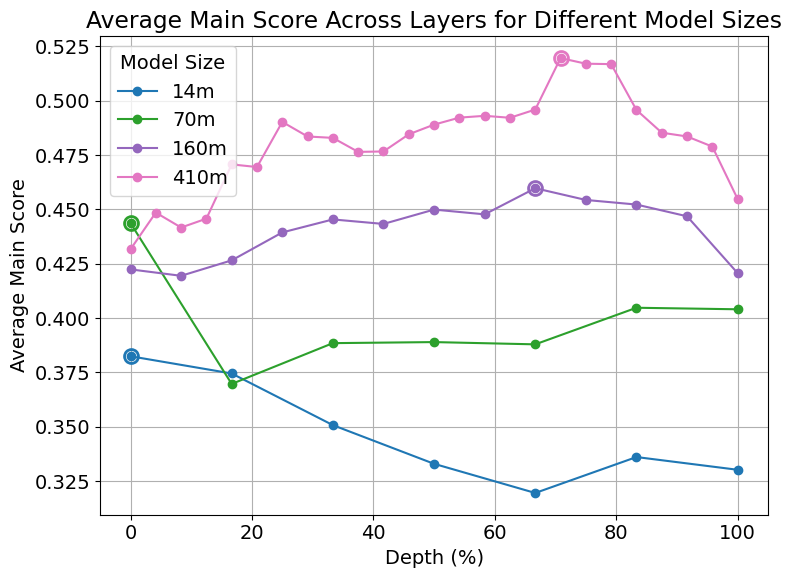

In [37]:
# plot performance across layers for Pythia 410m

# Get layer results for all Pythia sizes
model_family = 'Pythia'
model_sizes = ['14m', '70m', '160m', '410m']
revision = 'main'

plt.figure(figsize=(8, 6))

for model_size in model_sizes:
    layer_nums = []
    layer_scores = {}

    # Collect scores across layers
    for layer in all_results[model_family][model_size][revision].keys():
        if not layer.startswith('layer_'):
            continue
            
        layer_num = int(layer.split('_')[1])
        layer_nums.append(layer_num)
        
        layer_results = all_results[model_family][model_size][revision][layer]
        
        # Average main score across all tasks for this layer
        scores = []
        for task_name, task_results in layer_results.items():
            if 'main_score' in task_results:
                scores.append(task_results['main_score'])
                
        if scores:
            num_scores = len(scores)
            #print(f"Num. scores for size {model_size} layer {layer_num}: {num_scores}")
            layer_scores[layer_num] = np.mean(scores)

    # Sort by layer number
    layer_nums = sorted(layer_nums)
    max_layer = max(layer_nums)
    depth_percentages = [n/max_layer * 100 for n in layer_nums]
    scores = [layer_scores[n] for n in layer_nums]
    
    # Plot this model size
    line = plt.plot(depth_percentages, scores, marker='o', label=model_size)[0]
    
    # Find and circle highest point
    max_score_idx = np.argmax(scores)
    max_x = depth_percentages[max_score_idx]
    max_y = scores[max_score_idx]
    plt.plot(max_x, max_y, 'o', markersize=10, 
             markerfacecolor='none', markeredgecolor=line.get_color(),
             markeredgewidth=2)

plt.xlabel('Depth (%)')
plt.ylabel('Average Main Score')
plt.title('Average Main Score Across Layers for Different Model Sizes')
plt.grid(True)
plt.legend(title='Model Size')
plt.tight_layout()
# plt.savefig("figures/layer_performance_pythia_all_sizes.pdf")
plt.show()


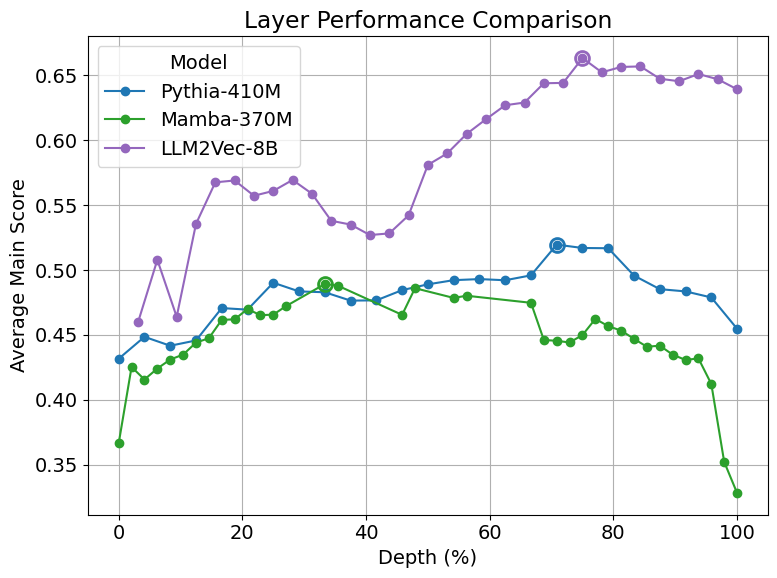

In [20]:
# plot Pythia-410m, mamba-370m, and LLM2Vec-mntp-unsup-simcse

model_families = ['Pythia', 'mamba', 'LLM2Vec-mntp-unsup-simcse']
model_sizes = ['410m', '370m', '8B']
model_labels = ['Pythia-410M', 'Mamba-370M', 'LLM2Vec-8B']

plt.figure(figsize=(8,6))

for model_family, model_size, model_label in zip(model_families, model_sizes, model_labels):
    layer_nums = []
    layer_scores = {}

    # Collect scores across layers
    for layer in all_results[model_family][model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        layer_num = int(layer.split('_')[1])
        layer_nums.append(layer_num)
        
        layer_results = all_results[model_family][model_size]['main'][layer]
        
        # Average main score across all tasks for this layer
        scores = []
        for task_name, task_results in layer_results.items():
            if 'main_score' in task_results:
                scores.append(task_results['main_score'])
                
        if scores:
            layer_scores[layer_num] = np.mean(scores)

    # Sort by layer number
    layer_nums = sorted(layer_nums)
    max_layer = max(layer_nums)
    depth_percentages = [n/max_layer * 100 for n in layer_nums]
    scores = [layer_scores[n] for n in layer_nums]
    
    # Plot this model
    if model_family == 'mamba':
        # Only plot points where score <= 0.6
        filtered_depths = []
        filtered_scores = []
        for d, s in zip(depth_percentages, scores):
            if s <= 0.6:
                filtered_depths.append(d)
                filtered_scores.append(s)
        line = plt.plot(filtered_depths, filtered_scores, marker='o', label=model_label)[0]
        # Find and circle highest point
        max_score_idx = np.argmax(filtered_scores)
        max_x = filtered_depths[max_score_idx]
        max_y = filtered_scores[max_score_idx]
    else:
        line = plt.plot(depth_percentages, scores, marker='o', label=model_label)[0]
        # Find and circle highest point
        max_score_idx = np.argmax(scores)
        max_x = depth_percentages[max_score_idx]
        max_y = scores[max_score_idx]
    
    plt.plot(max_x, max_y, 'o', markersize=10,
             markerfacecolor='none', markeredgecolor=line.get_color(),
             markeredgewidth=2)

plt.xlabel('Depth (%)')
plt.ylabel('Average Main Score')
plt.title('Layer Performance Comparison')
plt.grid(True)

plt.legend(title='Model')
plt.tight_layout()
#plt.savefig("figures/layer_performance_comparison.pdf")
plt.show()


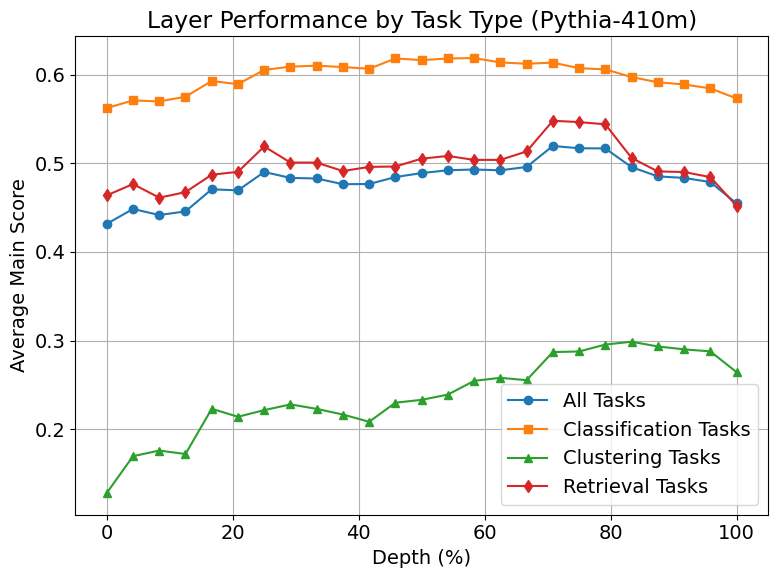

In [3]:
# for Pythia-410m, plot average across layers for all tasks, and classification tasks only, and clustering tasks only

# Get layer scores for Pythia-410m
layer_scores = {}
layer_nums = []
for layer in all_results['Pythia']['410m']['main'].keys():
    if not layer.startswith('layer_'):
        continue
        
    layer_num = int(layer.split('_')[1])
    layer_nums.append(layer_num)
    
    # Average main score across all tasks for this layer
    all_scores = []
    classification_scores = []
    clustering_scores = []
    retrieval_scores = []
    
    for task_name, task_results in all_results['Pythia']['410m']['main'][layer].items():
        if 'main_score' not in task_results:
            continue
            
        score = task_results['main_score']
        all_scores.append(score)
        
        # Split by task type
        if 'Classification' in task_name:
            classification_scores.append(score)
        elif 'Clustering' in task_name:
            clustering_scores.append(score)
        else:
            retrieval_scores.append(score)
            
    if all_scores:
        layer_scores[layer_num] = {
            'all': np.mean(all_scores),
            'classification': np.mean(classification_scores) if classification_scores else None,
            'clustering': np.mean(clustering_scores) if clustering_scores else None,
            'retrieval': np.mean(retrieval_scores) if retrieval_scores else None
        }

# Sort by layer number and prepare for plotting
layer_nums = sorted(layer_nums)
max_layer = max(layer_nums)
depth_percentages = [n/max_layer * 100 for n in layer_nums]

all_scores = [layer_scores[n]['all'] for n in layer_nums]
classification_scores = [layer_scores[n]['classification'] for n in layer_nums]
clustering_scores = [layer_scores[n]['clustering'] for n in layer_nums]
retrieval_scores = [layer_scores[n]['retrieval'] for n in layer_nums]
# Plot
plt.figure(figsize=(8, 6))
plt.plot(depth_percentages, all_scores, marker='o', label='All Tasks')
plt.plot(depth_percentages, classification_scores, marker='s', label='Classification Tasks')
plt.plot(depth_percentages, clustering_scores, marker='^', label='Clustering Tasks')
plt.plot(depth_percentages, retrieval_scores, marker='d', label='Retrieval Tasks')
plt.xlabel('Depth (%)')
plt.ylabel('Average Main Score')
plt.title('Layer Performance by Task Type (Pythia-410m)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


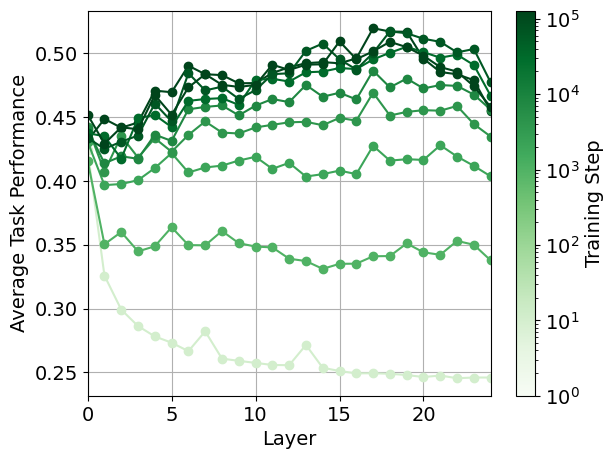

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors

models = ["Pythia"]
pythia_revision_steps = [1, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000]
revisions = ['main'] + [f"step{step}" for step in pythia_revision_steps]

# Create figure
fig, ax = plt.subplots(figsize=(6.5, 5))

cmap = plt.cm.Greens
norm = colors.LogNorm(vmin=min(pythia_revision_steps), vmax=max(pythia_revision_steps))

for revision in revisions:
    # Get all tasks for this revision
    layer_scores = {}
    layer_nums = []
    
    for layer in all_results['Pythia']['410m'][revision].keys():
        if not layer.startswith('layer_'):
            continue
            
        layer_num = int(layer.split('_')[1])
        layer_nums.append(layer_num)
        
        # Average main score across all tasks for this layer
        scores = []
        for task_name, task_results in all_results['Pythia']['410m'][revision][layer].items():
            if 'main_score' in task_results:
                scores.append(task_results['main_score'])
                
        if scores:
            layer_scores[layer_num] = np.mean(scores)

    # Sort by layer number
    layer_nums = sorted(layer_nums)
    scores = [layer_scores[n] for n in layer_nums]

    if revision == 'main':
        step = 143000
    else:
        step = int(revision.split('step')[1])
    if step < 10:
        color = cmap(norm(step) + 0.2)
    else:
        color = cmap(norm(step))

    ax.plot(layer_nums, scores, marker='o', color=color, label=f'Step {step}')

ax.set_xlabel('Layer')
ax.set_ylabel('Average Task Performance')
ax.grid(True)
ax.set_xlim(0, 24)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Training Step')

## Intra-model plots

In [135]:
all_results = load_all_results(should_normalize_scores_across_models=False)

In [136]:
print(all_results['Pythia']['410m']['main']['layer_0']['STS12'])

{'main_score': 0.40938250945908494, 'dataset_name': 'sts12-sts', 'entropy_dataset': {'maxEntropy': 0.4298711684623622, 'raw': 2.969444833228102, 'logN': 0.4298711684623622, 'logNlogD': 0.06201730029617941, 'logD': 0.42840033350915374}, 'dime': {'maxEntropy': 0.10002231279845412, 'raw': 0.690929659249524, 'logN': 0.10002231279845412, 'logNlogD': 0.014430169465257445, 'logD': 0.09968007930023895}, 'lidar': {'maxEntropy': 0.5758709517434574, 'raw': 3.977975606918335, 'logN': 0.5758709517434574, 'logNlogD': 0.08308061662722935, 'logD': 0.5739005680878346}, 'entropy_sentence': {'maxEntropy': 0.9726453323192084, 'raw': 2.804153955236666, 'logN': 0.9726453323192084, 'logNlogD': 0.1403230597480722, 'logD': 0.40455390051091145}, 'infonce': {'raw': 7.597357976786973}}


In [155]:
# get the best layer entropy for each task
model = 'Pythia'
size = '410m'
revision = 'main'
metric = 'entropy_sentence'

tasknames = []
for taskname, task_results in all_results[model][size][revision]['layer_0'].items():
    tasknames.append(taskname)

last_layer_idx = -1
last_layer_key = None
for layer in all_results[model][size][revision].keys():
    if not layer.startswith('layer_') or layer.endswith('last'):
        continue
    current_layer_idx = int(layer.split('_')[1])
    if current_layer_idx > last_layer_idx:
        last_layer_idx = current_layer_idx
        last_layer_key = layer

taskname_to_best_layer_idx = {}
taskname_to_best_layer_score = {}
taskname_to_best_layer_entropy = {}
taskname_to_last_layer_score = {}
taskname_to_last_layer_entropy = {}
taskname_to_first_layer_score = {}
taskname_to_first_layer_entropy = {}
for taskname in tasknames:
    best_score = 0
    best_entropy = 0
    last_layer_name = None
    for layer in all_results[model][size][revision].keys():
        if not layer.startswith('layer_') and not layer.endswith('last'):
            continue
        task_results = all_results[model][size][revision][layer][taskname]
        if metric in task_results:
            if task_results['main_score'] > best_score:
                best_score = task_results['main_score']
                best_layer_idx = int(layer.split('_')[1])
                try:
                    best_entropy = task_results[metric]['maxEntropy']
                except Exception as e:
                    print(model, size, revision, layer, taskname)
                    print(task_results[metric])
                    raise e

                    

    taskname_to_best_layer_score[taskname] = best_score
    taskname_to_best_layer_entropy[taskname] = best_entropy
    taskname_to_last_layer_score[taskname] = all_results[model][size][revision][last_layer_key][taskname]['main_score']
    taskname_to_first_layer_score[taskname] = all_results[model][size][revision]['layer_0'][taskname]['main_score']
    taskname_to_best_layer_idx[taskname] = best_layer_idx


    try:
        taskname_to_last_layer_entropy[taskname] = all_results[model][size][revision][last_layer_key][taskname][metric]['maxEntropy']
        taskname_to_first_layer_entropy[taskname] = all_results[model][size][revision]['layer_0'][taskname][metric]['maxEntropy']
    except Exception as e:
        taskname_to_last_layer_entropy[taskname] = -10000
        taskname_to_first_layer_entropy[taskname] = -10000


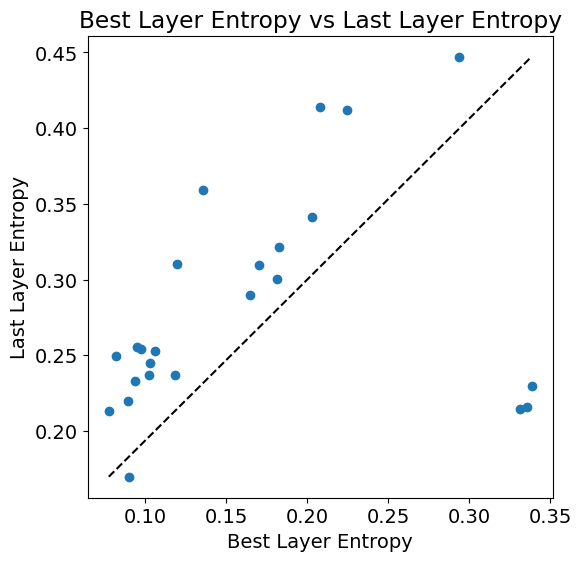

In [140]:
# plot the best layer entropy vs the last layer entropy, only for tasks with best layer entropy != -10000

best_layer_entropies = []
last_layer_entropies = []
for taskname in tasknames:
    if taskname_to_last_layer_entropy[taskname] != -10000:
        best_layer_entropies.append(taskname_to_best_layer_entropy[taskname])
        last_layer_entropies.append(taskname_to_last_layer_entropy[taskname])

# plot diagonal line
x_min, x_max = min(best_layer_entropies), max(best_layer_entropies)
y_min, y_max = min(last_layer_entropies), max(last_layer_entropies)
plt.figure(figsize=(6,6))
plt.scatter(best_layer_entropies, last_layer_entropies)
plt.plot([x_min, x_max], [y_min, y_max], color='black', linestyle='--')
plt.xlabel('Best Layer Entropy')
plt.ylabel('Last Layer Entropy')
plt.title('Best Layer Entropy vs Last Layer Entropy')
plt.show()

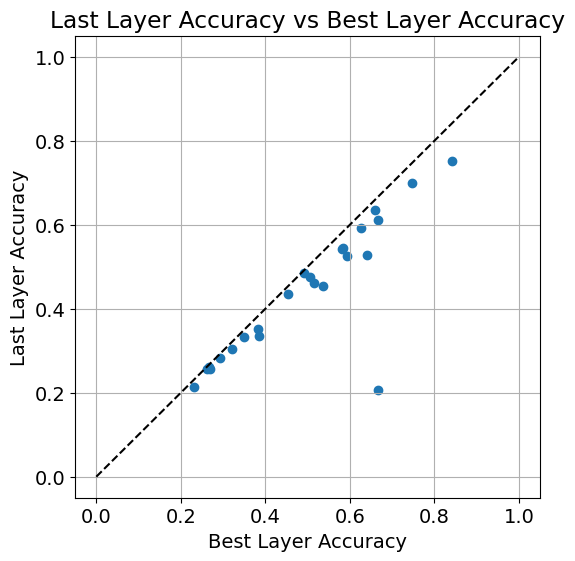

In [143]:
# plot the best layer accuracy vs the last layer accuracy

best_layer_scores = []
last_layer_scores = []
for taskname in tasknames:
    if taskname_to_last_layer_entropy[taskname] != -10000:
        best_layer_scores.append(taskname_to_best_layer_score[taskname])
        last_layer_scores.append(taskname_to_last_layer_score[taskname])

# plot diagonal line
x_min, x_max = min(best_layer_scores), max(best_layer_scores)
y_min, y_max = min(last_layer_scores), max(last_layer_scores)
plt.figure(figsize=(6,6))
plt.scatter(best_layer_scores, last_layer_scores)
#plt.plot([x_min, x_max], [y_min, y_max], color='black', linestyle='--')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('Best Layer Accuracy')
plt.ylabel('Last Layer Accuracy')
plt.grid(True)
plt.title('Last Layer Accuracy vs Best Layer Accuracy')
plt.show()

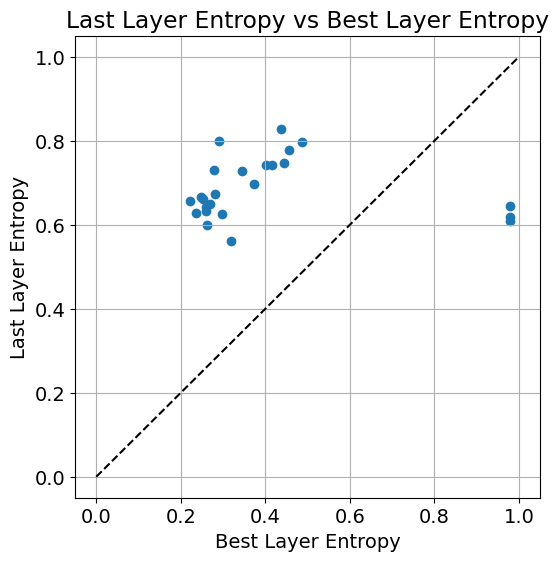

In [144]:
best_layer_scores = []
last_layer_scores = []
for taskname in tasknames:
    if taskname_to_last_layer_entropy[taskname] != -10000:
        best_layer_scores.append(taskname_to_best_layer_entropy[taskname])
        last_layer_scores.append(taskname_to_last_layer_entropy[taskname])

# plot diagonal line
x_min, x_max = min(best_layer_scores), max(best_layer_scores)
y_min, y_max = min(last_layer_scores), max(last_layer_scores)
plt.figure(figsize=(6,6))
plt.scatter(best_layer_scores, last_layer_scores)
#plt.plot([x_min, x_max], [y_min, y_max], color='black', linestyle='--')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('Best Layer Entropy')
plt.ylabel('Last Layer Entropy')
plt.title('Last Layer Entropy vs Best Layer Entropy')
plt.grid(True)
plt.show()

In [156]:
# find the task with highest best entropy
max_best_layer_entropy = max(best_layer_scores)
taskname_with_max_best_layer_entropy = None
for taskname in tasknames:
    if taskname_to_best_layer_entropy[taskname] == max_best_layer_entropy:
        taskname_with_max_best_layer_entropy = taskname
        break

print(taskname_with_max_best_layer_entropy)
print(taskname_to_best_layer_entropy[taskname_with_max_best_layer_entropy])

print(taskname_to_best_layer_idx['Banking77Classification'])


Banking77Classification
0.9795435002517653
1


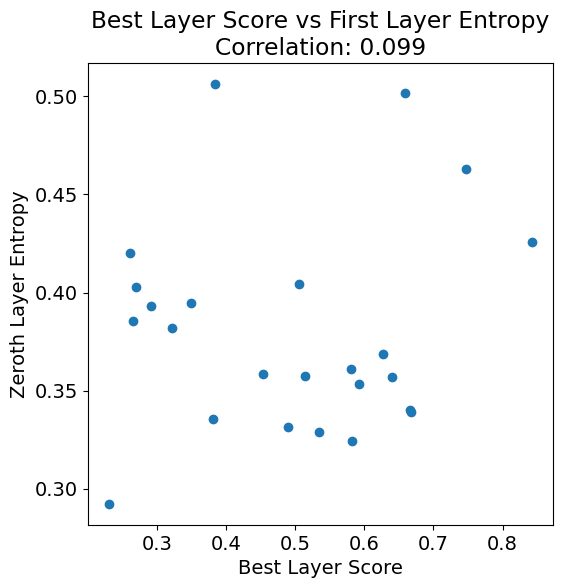

In [58]:
best_layer_scores = []
first_layer_entropies = []
for taskname in tasknames:
    if taskname_to_last_layer_entropy[taskname] != -10000:
        best_layer_scores.append(taskname_to_best_layer_score[taskname])
        first_layer_entropies.append(taskname_to_first_layer_entropy[taskname])

# Calculate correlation
correlation = np.corrcoef(best_layer_scores, first_layer_entropies)[0,1]

plt.figure(figsize=(6,6))
plt.scatter(best_layer_scores, first_layer_entropies)
plt.xlabel('Best Layer Score')
plt.ylabel('Zeroth Layer Entropy')
plt.title(f'Best Layer Score vs First Layer Entropy\nCorrelation: {correlation:.3f}')
plt.show()

## Inter-model Comparisons

In [99]:
all_results = load_all_results(should_normalize_scores_across_models=True)

nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
nan nan
0.08238777072876229 0.044221375547926066
0.13547985180383643 0.06486715142598705
0.0637125119934321 0.032425530765294246
0.27107962110929845 0.06125900358514008
0.0849435630072074 0.04573532922443504
0.05590774272874106 0.025846059306261944
0.25216403682210264 0.06605119639652308
0.21973921544712172 0.06989256995737061
0.20973915938905588 0.07117697600350187
0.10079347353120456 0.05340062901308837
0.16916173590196107 0.0702909320065953
0.1051224086453084 0.05547165205140949
0.05132999982034621 0.021606910806377923
0.18089218463850198 0.07113549478741234
0.09304569885112202 0.05023739936488629
0.23560076476643832 0.068363931446787
0.06971117211102534 0.0365488841842786
nan nan
0.22813076147469002 0.06913902372462442
0.07596353621481032 0.0407211329232

/home/AD/ofsk222/Research/exploration/information_plane/experiments/utils/misc/results_saving.py:201: RuntimeWarning: invalid value encountered in scalar divide
  all_results[model_family][model_size][revision][layer][task_name]['standardized_main_score'] = (all_results[model_family][model_size][revision][layer][task_name]['main_score'] - mean_main_score) / std_main_score


In [103]:
model = 'Pythia'
revision = 'main'
metric = 'entropy_sentence'
sizes = ['14m', '70m', '160m', '410m']

taskname_to_best_layer_score = {}
taskname_to_best_layer_entropy = {}
taskname_to_last_layer_score = {}
taskname_to_last_layer_entropy = {}
taskname_to_first_layer_score = {}
taskname_to_first_layer_entropy = {}

for size in sizes:
    if size not in all_results[model]:
        continue

    tasknames = []
    for taskname, task_results in all_results[model][size][revision]['layer_0'].items():
        tasknames.append(taskname)

    last_layer_idx = -1
    last_layer_key = None
    for layer in all_results[model][size][revision].keys():
        if not layer.startswith('layer_') or layer.endswith('last'):
            continue
        current_layer_idx = int(layer.split('_')[1])
        if current_layer_idx > last_layer_idx:
            last_layer_idx = current_layer_idx
            last_layer_key = layer

    if size not in taskname_to_best_layer_score:
        taskname_to_best_layer_score[size] = {}
        taskname_to_best_layer_entropy[size] = {}
        taskname_to_last_layer_score[size] = {}
        taskname_to_last_layer_entropy[size] = {}
        taskname_to_first_layer_score[size] = {}
        taskname_to_first_layer_entropy[size] = {}

    for taskname in tasknames:
        best_score = 0
        best_entropy = 0
        last_layer_name = None
        for layer in all_results[model][size][revision].keys():
            if not layer.startswith('layer_') or layer.endswith('last'):
                continue
            task_results = all_results[model][size][revision][layer][taskname]
            if metric in task_results:
                best_score = max(best_score, task_results['standardized_main_score'])
                best_entropy = max(best_entropy, task_results[metric]['standardized_logD'])

        taskname_to_best_layer_score[size][taskname] = best_score
        taskname_to_best_layer_entropy[size][taskname] = best_entropy
        taskname_to_last_layer_score[size][taskname] = all_results[model][size][revision][last_layer_key][taskname]['standardized_main_score']
        taskname_to_first_layer_score[size][taskname] = all_results[model][size][revision]['layer_0'][taskname]['standardized_main_score']

        try:
            taskname_to_last_layer_entropy[size][taskname] = all_results[model][size][revision][last_layer_key][taskname][metric]['standardized_logD']
            taskname_to_first_layer_entropy[size][taskname] = all_results[model][size][revision]['layer_0'][taskname][metric]['standardized_logD']
        except Exception as e:
            taskname_to_last_layer_entropy[size][taskname] = -10000
            taskname_to_first_layer_entropy[size][taskname] = -10000

In [104]:
all_results['Pythia']['410m']['main']['layer_0']['STS12']

{'main_score': 0.40938250945908494,
 'dataset_name': 'sts12-sts',
 'entropy_dataset': {'logD': 0.42840033350915374},
 'dime': {'logD': 0.09968007930023895},
 'lidar': {'logD': 0.5739005680878346},
 'entropy_sentence': {'logD': 0.40455390051091145,
  'standardized_logD': 0.4605649631441837},
 'infonce': {'raw': 7.597357976786973},
 'standardized_main_score': -0.10718255883501292}

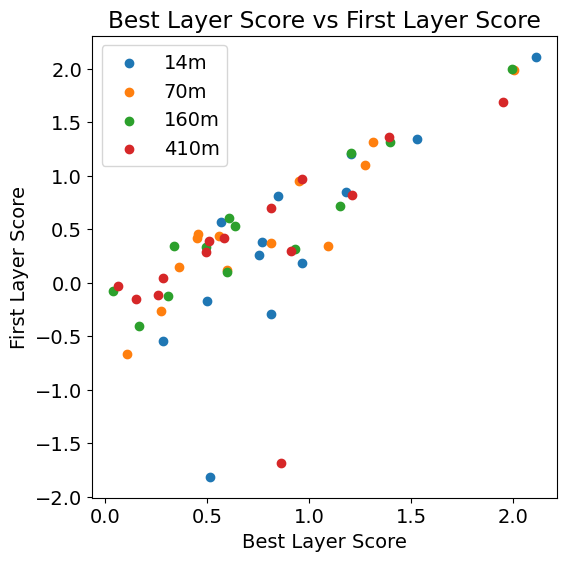

In [107]:
# for all sizes, plot the best layer entropy vs the last layer entropy on the same plot

plt.figure(figsize=(6,6))

for size in sizes:
    best_layer_entropies = []
    last_layer_entropies = []
    for taskname in tasknames:
        if taskname_to_last_layer_entropy[size][taskname] != -10000 and taskname_to_best_layer_score[size][taskname] != 0:
            best_layer_entropies.append(taskname_to_best_layer_score[size][taskname])
            last_layer_entropies.append(taskname_to_last_layer_score[size][taskname])

    plt.scatter(best_layer_entropies, last_layer_entropies, label=size)

plt.xlabel('Best Layer Score')
plt.ylabel('First Layer Score') 
plt.title('Best Layer Score vs First Layer Score')

x_min, x_max = min(best_layer_scores), max(best_layer_scores)
y_min, y_max = min(last_layer_scores), max(last_layer_scores)
#plt.plot([x_min, x_max], [y_min, y_max], color='black', linestyle='--')

plt.legend()
plt.show()